In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Load Dataset
df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')

# 2. Pembersihan Ekstrim (Regex)
# Ngatasin masalah kayak '37Bachelor' -> ambil angkanya aja
df['Age'] = df['Age'].astype(str).str.extract('(\d+)').astype(float)
df['Team_Size'] = df['Team_Size'].astype(str).str.extract('(\d+)').astype(float)

# 3. Handling Missing Values (Imputasi, jangan asal buang)
# Isi Age yang kosong pake Median biar stabil
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Team_Size'] = df['Team_Size'].fillna(df['Team_Size'].median())

# 4. Encoding yang Konsisten
edu_map = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df['Education_Level'] = df['Education_Level'].map(edu_map).fillna(1) # Default ke High School kalau aneh

# One-Hot Encoding buat semua kategori biar AI gak bingung urutan angka
# Department, Gender, dan Job_Title dibikin kolom sendiri-sendiri
df = pd.get_dummies(df, columns=['Gender', 'Job_Title', 'Department'], drop_first=True)

# 5. Fitur & Target
# Pastiin 'Resigned' gak ikutan masuk ke fitur Performance_Score
X = df.drop(['Employee_ID', 'Hire_Date', 'Performance_Score', 'Resigned'], axis=1)
y = df['Performance_Score']

# 6. Split & Scale
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Data Berhasil Diselamatkan! Total baris: {len(df)}")

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_8524\170482091.py:12: SyntaxWarning: invalid escape sequence '\d'
  df['Age'] = df['Age'].astype(str).str.extract('(\d+)').astype(float)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8524\170482091.py:13: SyntaxWarning: invalid escape sequence '\d'
  df['Team_Size'] = df['Team_Size'].astype(str).str.extract('(\d+)').astype(float)


Data Berhasil Diselamatkan! Total baris: 100000


Sedang melatih Baseline Linear Regression...

--- Hasil Evaluasi Baseline (Linear Regression) ---
MAE      : 0.1875 (Semakin kecil semakin baik)
RMSE     : 0.2532 (Sensitif terhadap outlier)
R2 Score : 0.9679 (Mendekati 1.0 = Sangat Akurat)

--- Analisis Bobot Fitur (Coefficient) ---
                          Fitur  Bobot_Koefisien
3                Monthly_Salary         2.691812
20         Job_Title_Technician         0.445402
21       Department_Engineering         0.002372
23                Department_HR         0.001521
24                Department_IT         0.001319
4           Work_Hours_Per_Week         0.001133
27        Department_Operations         0.000971
6                Overtime_Hours         0.000922
26         Department_Marketing         0.000887
8         Remote_Work_Frequency         0.000779
22           Department_Finance         0.000742
11                   Promotions         0.000705
9                     Team_Size         0.000645
28             Department_Sal

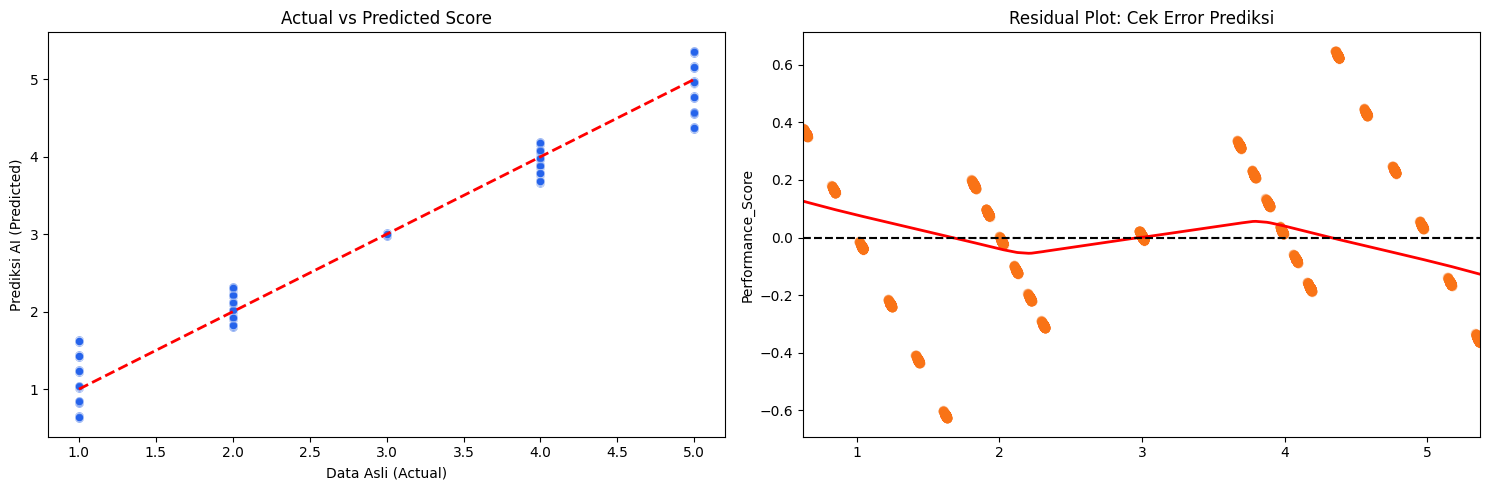


[INFO] Model Baseline Berhasil Disimpan!


In [11]:
# ==========================================
# 2. LINEAR REGRESSION (BASELINE MODEL)
# ==========================================
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Inisialisasi Model
# Kita tidak pakai random_state di sini karena Linear Regression (OLS) bersifat deterministik
lr_model = LinearRegression()

# 2. Training Model
print("Sedang melatih Baseline Linear Regression...")
lr_model.fit(X_train_scaled, y_train)

# 3. Prediksi pada Data Test
y_pred_lr = lr_model.predict(X_test_scaled)

# 4. Hitung Metrik Evaluasi secara Presisi
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n--- Hasil Evaluasi Baseline (Linear Regression) ---")
print(f"MAE      : {mae_lr:.4f} (Semakin kecil semakin baik)")
print(f"RMSE     : {rmse_lr:.4f} (Sensitif terhadap outlier)")
print(f"R2 Score : {r2_lr:.4f} (Mendekati 1.0 = Sangat Akurat)")

# 5. ANALISIS FITUR: Kenapa AI Memutuskan Demikian?
# Ini kunci buat ngejelasin ke dosen kenapa 100 jam tetep bertahan
coeffs = pd.DataFrame({
    'Fitur': X.columns,
    'Bobot_Koefisien': lr_model.coef_
}).sort_values(by='Bobot_Koefisien', ascending=False)

print("\n--- Analisis Bobot Fitur (Coefficient) ---")
print(coeffs)

# 6. VISUALISASI HASIL (Bahan Presentasi)
plt.figure(figsize=(15, 5))

# Subplot 1: Scatter Plot Prediksi vs Aktual
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.3, color='#2563eb')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Score')
plt.xlabel('Data Asli (Actual)')
plt.ylabel('Prediksi AI (Predicted)')

# Subplot 2: Residual Plot (Untuk deteksi Non-Linearitas)
plt.subplot(1, 2, 2)
sns.residplot(x=y_pred_lr, y=y_test - y_pred_lr, lowess=True, 
              line_kws={'color': 'red', 'lw': 2},
              scatter_kws={'alpha': 0.3, 'color': '#f97316'})
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot: Cek Error Prediksi')
plt.tight_layout()
plt.show()

# 7. Simpan Model Baseline
joblib.dump(lr_model, 'model_baseline_lr.pkl')
print("\n[INFO] Model Baseline Berhasil Disimpan!")

Memulai Training ANN (Versi Anti-Mabuk)...
Epoch 1/50


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8540 - mae: 0.6649 - val_loss: 0.0504 - val_mae: 0.1811
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1349 - mae: 0.2813 - val_loss: 0.0351 - val_mae: 0.1531
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0710 - mae: 0.2021 - val_loss: 0.0425 - val_mae: 0.1706
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0442 - mae: 0.1562 - val_loss: 0.0506 - val_mae: 0.1748
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0283 - mae: 0.1222 - val_loss: 0.0632 - val_mae: 0.1858
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0199 - mae: 0.1004 - val_loss: 0.0587 - val_mae: 0.1769
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0149 - mae: 0.0850 - val_loss: 0.0592 - val_mae: 0.1751
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step

--- Hasil Evaluasi Final ANN ---
MAE  : 0.1531
RMSE : 0.1872


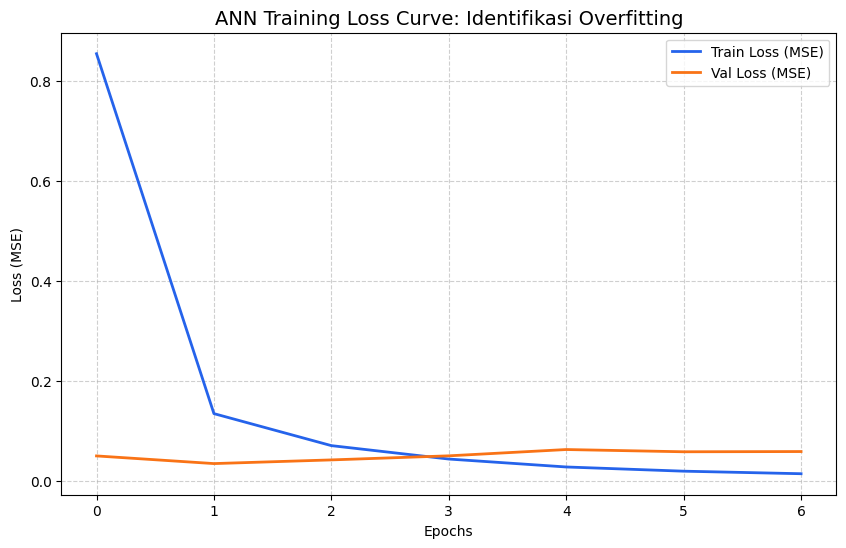


Menyimpan Model dan Scaler...
Semua file berhasil disimpan. Siap lanjut ke Website!


In [12]:
# ==========================================
# 3. ARTIFICIAL NEURAL NETWORK (ANN) - FINAL
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import matplotlib.pyplot as plt

# 1. Mengunci Random Seed agar hasil konsisten di VS Code & Colab
np.random.seed(42)
tf.random.set_seed(42)

# 2. Membangun Arsitektur ANN (Deep Learning)
model_ann = Sequential([
    # Input Layer & Hidden Layer 1
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Mencegah Overfitting
    
    # Hidden Layer 2
    Dense(64, activation='relu'),
    Dropout(0.1),
    
    # Hidden Layer 3 (Kompresi Fitur)
    Dense(32, activation='relu'),
    
    # Output Layer (Prediksi Skor 0-100)
    Dense(1) 
])

# 3. Compile Model
# Adam optimizer sangat stabil untuk dataset 100k baris
model_ann.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Setting Early Stopping (Garda Keamanan)
callback = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True 
)

# 5. Training Model
print("Memulai Training ANN (Versi Anti-Mabuk)...")
history_ann = model_ann.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val), # Gunakan data validasi
    epochs=50, 
    batch_size=128, 
    callbacks=[callback],
    verbose=1
)

# 6. Evaluasi Akhir (Prediksi pada X_test_scaled)
y_pred_ann = model_ann.predict(X_test_scaled)
mae_ann = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))

print(f"\n--- Hasil Evaluasi Final ANN ---")
print(f"MAE  : {mae_ann:.4f}")
print(f"RMSE : {rmse_ann:.4f}")

# 7. Visualisasi Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['loss'], label='Train Loss (MSE)', color='#2563eb', lw=2)
plt.plot(history_ann.history['val_loss'], label='Val Loss (MSE)', color='#f97316', lw=2)
plt.title('ANN Training Loss Curve: Identifikasi Overfitting', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 8. SIMPAN AMUNISI UNTUK FLASK (PENTING!)
print("\nMenyimpan Model dan Scaler...")
model_ann.save('model_ann_fixed.h5') # Model Deep Learning
joblib.dump(scaler, 'scaler_ann.pkl') # Scaler wajib dibawa ke Flask!
print("Semua file berhasil disimpan. Siap lanjut ke Website!")

Memulai Training RNN/LSTM (Deep Learning)...
Epoch 1/50


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.4739 - mae: 0.7332 - val_loss: 0.0126 - val_mae: 0.0887
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0889 - mae: 0.2269 - val_loss: 0.0049 - val_mae: 0.0561
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0572 - mae: 0.1784 - val_loss: 0.0036 - val_mae: 0.0480
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0440 - mae: 0.1550 - val_loss: 0.0029 - val_mae: 0.0431
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0373 - mae: 0.1423 - val_loss: 0.0030 - val_mae: 0.0442
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0317 - mae: 0.1322 - val_loss: 0.0023 - val_mae: 0.0380
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0257 - mae: 0.1177 - val_loss: 0.0027 - val_mae: 0.0420
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0213 - mae: 0.1057 - val_loss: 0.0016 - val_mae: 0.0311
Epoch 9/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0161 

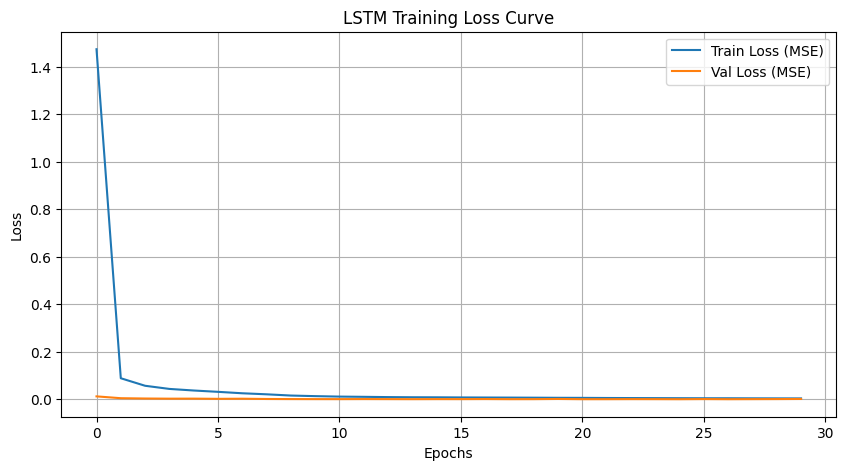


--- Hasil Evaluasi RNN/LSTM ---
MAE  : 0.0206
RMSE : 0.0251
MAPE : 0.0094


In [13]:
# ==========================================
# 3. RECURRENT NEURAL NETWORK (LSTM)
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Reshape data menjadi 3D [samples, time_steps, features]
# Time_steps = 1 karena kita menganggap setiap baris adalah satu kejadian
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_rnn = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 2. Bangun Arsitektur LSTM yang Robust
model_rnn = Sequential([
    # Layer LSTM pertama (return_sequences=True jika ada layer LSTM berikutnya)
    LSTM(64, activation='tanh', input_shape=(1, X_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    
    # Layer LSTM kedua
    LSTM(32, activation='tanh'),
    Dropout(0.1),
    
    # Fully Connected Layer
    Dense(16, activation='relu'),
    Dense(1) # Output untuk Performance_Score
])

# 3. Compile Model
model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Early Stopping (Penting agar tidak overfitting seperti ANN kemarin)
callback_rnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5. Training Model
print("Memulai Training RNN/LSTM (Deep Learning)...")
history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=50, 
    batch_size=128,
    callbacks=[callback_rnn],
    verbose=1
)

# 6. Evaluasi Metrik
y_pred_rnn = model_rnn.predict(X_test_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mape_rnn = mean_absolute_percentage_error(y_test, y_pred_rnn)

# 7. Visualisasi Training
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['loss'], label='Train Loss (MSE)')
plt.plot(history_rnn.history['val_loss'], label='Val Loss (MSE)')
plt.title('LSTM Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 8. Simpan Model
model_rnn.save('model_rnn_fixed.h5')

print("\n--- Hasil Evaluasi RNN/LSTM ---")
print(f"MAE  : {mae_rnn:.4f}")
print(f"RMSE : {rmse_rnn:.4f}")
print(f"MAPE : {mape_rnn:.4f}")

Memulai Training RNN/LSTM (Algoritma 3)...
Epoch 1/50


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.5768 - mae: 0.7668 - val_loss: 0.0137 - val_mae: 0.0926
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0956 - mae: 0.2359 - val_loss: 0.0077 - val_mae: 0.0678
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0626 - mae: 0.1870 - val_loss: 0.0044 - val_mae: 0.0533
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0462 - mae: 0.1596 - val_loss: 0.0041 - val_mae: 0.0502
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0361 - mae: 0.1403 - val_loss: 0.0030 - val_mae: 0.0453
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0265 - mae: 0.1188 - val_loss: 0.0022 - val_mae: 0.0356
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0192 - mae: 0.0996 - val_loss: 0.0011 - val_mae: 0.0266
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0164 - mae: 0.0931 - val_loss: 0.0013 - val_mae: 0.0277
Epoch 9/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0142 


--- Hasil Evaluasi RNN/LSTM ---
MAE  : 0.0128
RMSE : 0.0176
MAPE : 0.0047 (Persentase Error)


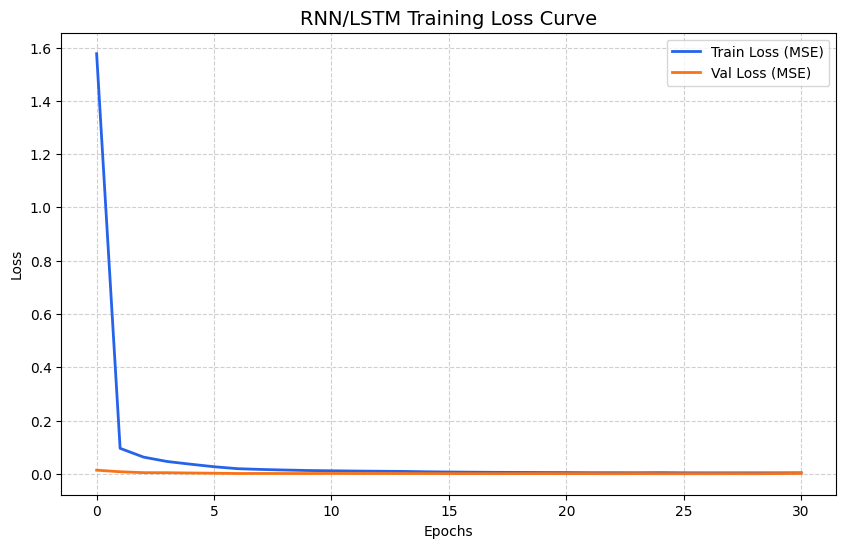

In [14]:
# ==========================================
# 3. RECURRENT NEURAL NETWORK (RNN / LSTM)
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Reshape data menjadi 3D [samples, time_steps, features]
# Kita set time_step = 1 karena tiap baris data adalah satu observasi independen
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_rnn = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 2. Bangun Arsitektur LSTM yang Robust
model_rnn = Sequential([
    # Layer LSTM pertama - Pake 'tanh' biar stabil sesuai standar RNN
    LSTM(64, activation='tanh', input_shape=(1, X_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    
    # Layer LSTM kedua
    LSTM(32, activation='tanh'),
    Dropout(0.1),
    
    # Fully Connected Layer (Deeper Learning)
    Dense(16, activation='relu'),
    Dense(1) # Output untuk Performance_Score
])

# 3. Compile Model
model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Early Stopping (Garda Keamanan)
# Berhenti kalau Val Loss gak turun dalam 5 epoch
stop_rnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 5. Training
print("Memulai Training RNN/LSTM (Algoritma 3)...")
history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=50, # Set lebih tinggi, EarlyStopping yang akan ngerem
    batch_size=128,
    callbacks=[stop_rnn],
    verbose=1
)

# 6. Evaluasi Sesuai Tabel UTS
y_pred_rnn = model_rnn.predict(X_test_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mape_rnn = mean_absolute_percentage_error(y_test, y_pred_rnn)

# 7. Simpan Model untuk Website
model_rnn.save('model_rnn_fixed.h5')

print("\n--- Hasil Evaluasi RNN/LSTM ---")
print(f"MAE  : {mae_rnn:.4f}")
print(f"RMSE : {rmse_rnn:.4f}")
print(f"MAPE : {mape_rnn:.4f} (Persentase Error)")

# 8. Visualisasi Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Train Loss (MSE)', color='#2563eb', lw=2)
plt.plot(history_rnn.history['val_loss'], label='Val Loss (MSE)', color='#f97316', lw=2)
plt.title('RNN/LSTM Training Loss Curve', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

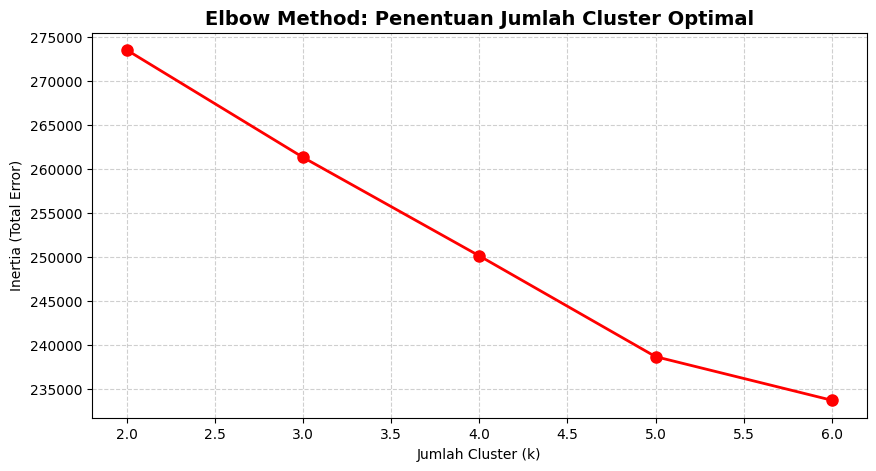


--- ANALISIS RATA-RATA PER CLUSTER ---
               Age  Monthly_Salary  Work_Hours_Per_Week  Years_At_Company  \
Cluster                                                                     
0        40.960416     4546.396441            44.922231          4.492903   
1        41.029828     7581.890908            45.008351          4.473679   
2        41.004891     5850.552321            44.975478          4.468574   

         Employee_Satisfaction_Score  
Cluster                               
0                           2.999197  
1                           3.003163  
2                           3.000317  


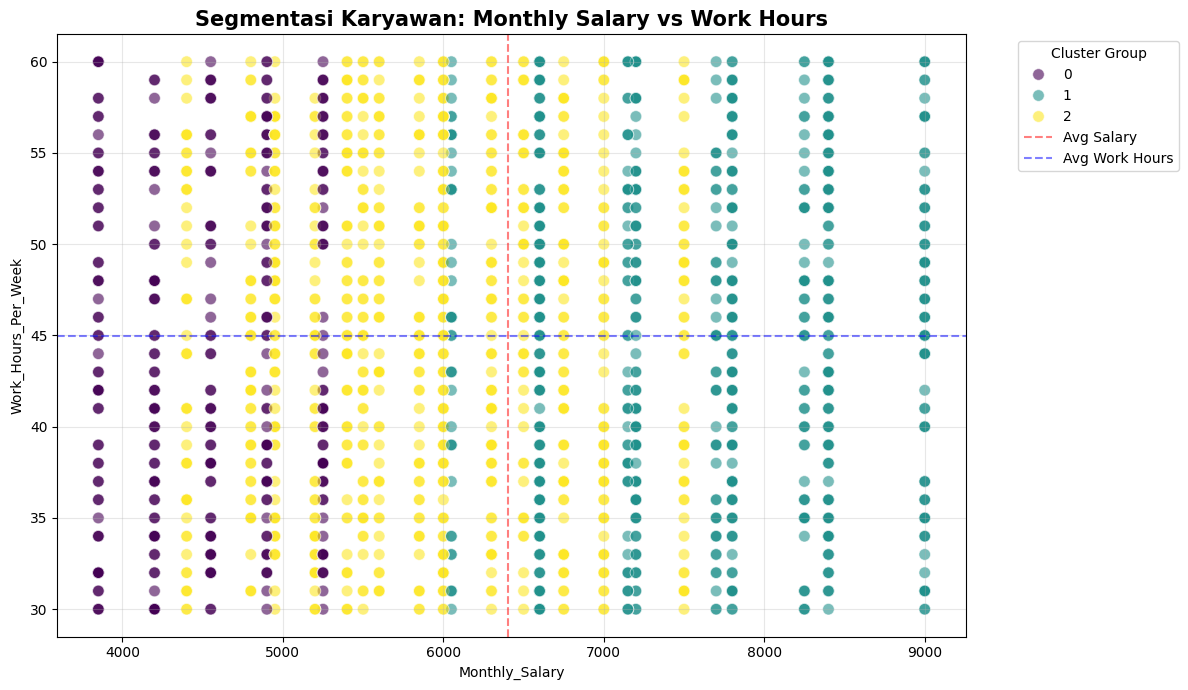


[INFO] Model K-Means Berhasil Disimpan!


In [16]:
# ==========================================
# 4. K-MEANS CLUSTERING (UNSUPERVISED)
# ==========================================
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib

# 1. Elbow Method (Mencari Jumlah Cluster Terbaik)
inertia = []
K_range = range(2, 7)
sample_size = 10000 

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Gunakan sampling agar proses pencarian 'siku' lebih cepat
    km.fit(X_train_scaled[:sample_size])
    inertia.append(km.inertia_)

# Visualisasi Elbow Plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'ro-', markersize=8, lw=2)
plt.title('Elbow Method: Penentuan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (Total Error)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Eksekusi K-Means Final (K=3)
# Kita bagi karyawan jadi 3 kelompok utama
k_best = 3
kmeans_final = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_train_scaled)

# Masukkan hasil cluster ke copy dari DataFrame asli (X_train)
X_train_with_cluster = X_train.copy()
X_train_with_cluster['Cluster'] = clusters

# 3. ANALISIS KARAKTERISTIK (Sesuai Nama Kolom Asli Lu)
cluster_analysis = X_train_with_cluster.groupby('Cluster').mean()

print("\n" + "="*50)
print("--- ANALISIS RATA-RATA PER CLUSTER ---")
print("="*50)
# Memilih kolom kunci untuk interpretasi profil karyawan
cols_to_show = [
    'Age', 'Monthly_Salary', 'Work_Hours_Per_Week', 
    'Years_At_Company', 'Employee_Satisfaction_Score'
]
# Pastikan hanya kolom yang ada di dataset yang ditampilkan
existing_cols = [c for c in cols_to_show if c in cluster_analysis.columns]
print(cluster_analysis[existing_cols])

# 4. VISUALISASI SEBARAN (Gaji vs Jam Kerja Mingguan)
plt.figure(figsize=(12, 7))
# Gunakan sample 2000 data biar plot tetap ringan tapi representatif
sns.scatterplot(
    data=X_train_with_cluster.sample(2000, random_state=42), 
    x='Monthly_Salary', 
    y='Work_Hours_Per_Week', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=70,
    edgecolor='w'
)

# Tambahkan garis rata-rata (Crosshair) untuk melihat posisi tiap cluster
plt.axvline(X_train['Monthly_Salary'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Salary')
plt.axhline(X_train['Work_Hours_Per_Week'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg Work Hours')

plt.title('Segmentasi Karyawan: Monthly Salary vs Work Hours', fontsize=15, fontweight='bold')
plt.legend(title='Cluster Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Simpan Model untuk Website
joblib.dump(kmeans_final, 'model_kmeans.pkl')
print("\n[INFO] Model K-Means Berhasil Disimpan!")

Memulai Training Backpropagation Klasifikasi...
Epoch 1/100


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8988 - loss: 0.3355 - val_accuracy: 0.8997 - val_loss: 0.3298
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8995 - loss: 0.3296 - val_accuracy: 0.8997 - val_loss: 0.3289
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8995 - loss: 0.3286 - val_accuracy: 0.8997 - val_loss: 0.3283
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8995 - loss: 0.3275 - val_accuracy: 0.8997 - val_loss: 0.3280
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8995 - loss: 0.3268 - val_accuracy: 0.8997 - val_loss: 0.3279
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8995 - loss: 0.3265 - val_accuracy: 0.8997 - val_loss: 0.3277
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8995 - loss: 0.3260 - val_accuracy: 0.8997 - val_loss: 0.3283
Epoch 8/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8995 - loss: 0.3259 - val_

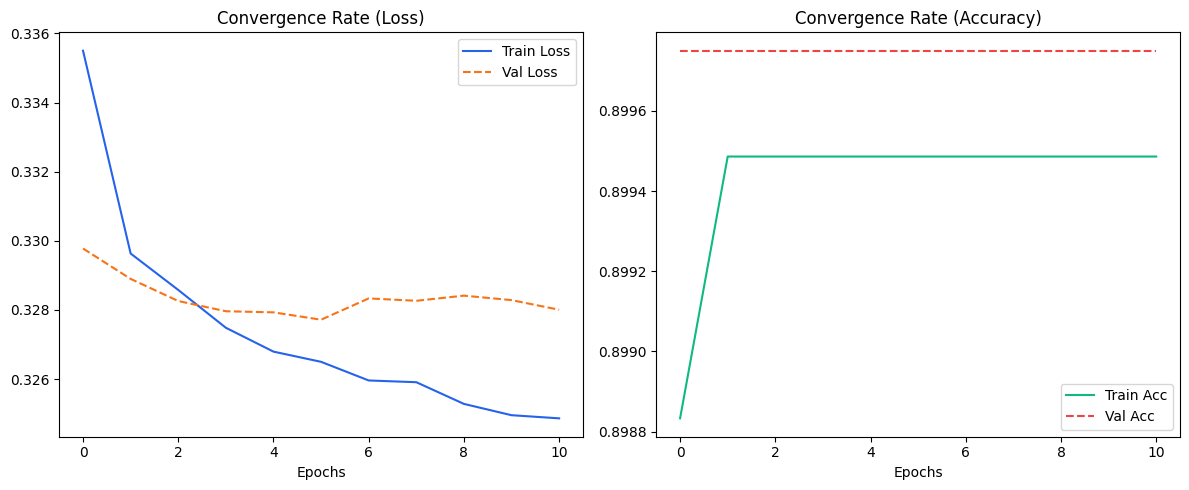


--- STATUS FINAL ---


Final Accuracy Classification : 0.9014

Semua 'Amunisi' Berhasil Disimpan!
Jumlah Fitur yang tersimpan di Scaler: 29
File tersimpan: model_backprop.h5, scaler.joblib


In [18]:
# ==========================================
# 5. BACKPROPAGATION CLASSIFICATION & EXPORT (FIXED)
# ==========================================
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Persiapan Data (Target: Resigned)
# Kita gunakan X yang sudah melewati proses preprocessing terakhir
y_bp = df['Resigned'].astype(int)
X_train_bp, X_test_bp, y_train_bp, y_test_bp = train_test_split(X, y_bp, test_size=0.2, random_state=42)

# Normalisasi: Sangat Krusial untuk Convergence Rate Backprop
# Kita buat scaler_final yang akan jadi 'gerbang' utama di Flask nanti
scaler_final = StandardScaler()
X_train_bp_s = scaler_final.fit_transform(X_train_bp)
X_test_bp_s = scaler_final.transform(X_test_bp)

# 2. Inisialisasi Early Stopping
# Mencegah model belajar terlalu lama jika akurasi sudah tidak naik
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Arsitektur Model (Sesuai instruksi UTS: Tanh & Relu)
model_bp = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_bp_s.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid untuk klasifikasi biner (0 atau 1)
])

# 4. Compile & Training
model_bp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Memulai Training Backpropagation Klasifikasi...")
history_bp = model_bp.fit(
    X_train_bp_s, y_train_bp,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 5. Visualisasi Hasil
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_bp.history['loss'], label='Train Loss', color='#2563eb')
plt.plot(history_bp.history['val_loss'], label='Val Loss', color='#f97316', linestyle='--')
plt.title('Convergence Rate (Loss)')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_bp.history['accuracy'], label='Train Acc', color='#10b981')
plt.plot(history_bp.history['val_accuracy'], label='Val Acc', color='#ef4444', linestyle='--')
plt.title('Convergence Rate (Accuracy)')
plt.xlabel('Epochs')
plt.legend()
plt.tight_layout()
plt.show()

# 6. STATUS FINAL & EXPORT
print("\n--- STATUS FINAL ---")
loss_bp, acc_bp = model_bp.evaluate(X_test_bp_s, y_test_bp, verbose=0)
print(f"Final Accuracy Classification : {acc_bp:.4f}")

# Simpan Model Klasifikasi (H5 format stabil untuk Flask)
model_bp.save('model_backprop.h5')

# Simpan Scaler (Menggunakan joblib agar konsisten dengan load di app.py)
joblib.dump(scaler_final, 'scaler.joblib')

print("\nSemua 'Amunisi' Berhasil Disimpan!")
# Menggunakan X_train_bp untuk menghindari NameError X_final
print(f"Jumlah Fitur yang tersimpan di Scaler: {X_train_bp.shape[1]}")
print("File tersimpan: model_backprop.h5, scaler.joblib")